In [1]:
from src import config, evaluate
from src.ingest.synthetic_adapter import SyntheticAdapter
from src.bars import build_bars
from src.features import compute_features
from src.backtest import train_and_backtest
from src.detector import Detector
import matplotlib.pyplot as plt

In [2]:
adapter = SyntheticAdapter(n_days=30, seed=7)
events = list(adapter.stream())     # consume the stream (this also fills .truth)
truth = adapter.truth
print(f"{len(events)} raw events")
events[:4]                          # <-- see the canonical quote/trade dicts

44111 raw events


[{'ts': '2026-01-05T09:00:00+07:00',
  'type': 'quote',
  'symbol': 'DEMO',
  'bid': 4995.0,
  'ask': 5000.0,
  'bid_size': 800,
  'ask_size': 1373},
 {'ts': '2026-01-05T09:00:06.818182+07:00',
  'type': 'trade',
  'symbol': 'DEMO',
  'price': 4995.0,
  'size': 37,
  'aggressor': 'sell'},
 {'ts': '2026-01-05T09:00:13.636364+07:00',
  'type': 'quote',
  'symbol': 'DEMO',
  'bid': 4993.0,
  'ask': 4998.0,
  'bid_size': 803,
  'ask_size': 778},
 {'ts': '2026-01-05T09:00:20.454546+07:00',
  'type': 'trade',
  'symbol': 'DEMO',
  'price': 4998.0,
  'size': 54,
  'aggressor': 'buy'}]

In [3]:
bars = build_bars(iter(events))
print(bars.shape)
bars.head()                         # <-- OHLC, volume, ofi, avg_spread, slot, ...

(924, 17)


,open,high,low,close,vwap,volume,buy_vol,sell_vol,signed_vol,n_trades,ofi,avg_spread,realized_vol,session_id,bar_in_session,slot,date
bar_start,,,,,,,,,,,,,,,,,
2026-01-05 09:00:00+07:00,4997.5,5015.5,4993.5,5004.5,5005.897302,2113,629,1484,-855,32,13826.0,5.0,0.000497,0,0,09:00,2026-01-05
2026-01-05 09:10:00+07:00,5003.5,5003.5,4963.5,4967.5,4980.667870,1108,573,535,38,14,-18242.0,5.0,0.000588,0,1,09:10,2026-01-05
2026-01-05 09:20:00+07:00,4963.0,4964.0,4921.0,4926.0,4942.909188,936,540,396,144,20,-18912.0,4.0,0.000563,0,2,09:20,2026-01-05
2026-01-05 09:30:00+07:00,4922.0,4927.0,4915.0,4924.0,4921.086608,1374,561,813,-252,16,-4252.0,4.0,0.000667,0,3,09:30,2026-01-05
2026-01-05 09:40:00+07:00,4921.0,4921.0,4882.0,4882.0,4901.519010,1657,1186,471,715,23,-29787.0,4.0,0.000589,0,4,09:40,2026-01-05


In [4]:
feats = compute_features(bars)
print(feats.shape, "| columns:", list(feats.columns))
feats.head()                          # <-- the 6 model features + context columns

(864, 10) | columns: ['ret', 'signed_vol_imb', 'ofi', 'rel_spread', 'realized_vol', 'trade_intensity', 'close', 'slot', 'session_id', 'date']


,ret,signed_vol_imb,ofi,rel_spread,realized_vol,trade_intensity,close,slot,session_id,date
bar_start,,,,,,,,,,
2026-01-05 09:10:00+07:00,-0.007421,0.034296,-18242.0,0.001007,0.000588,14.0,4967.5,09:10,0,2026-01-05
2026-01-05 09:20:00+07:00,-0.008389,0.153846,-18912.0,0.000812,0.000563,20.0,4926.0,09:20,0,2026-01-05
2026-01-05 09:30:00+07:00,-0.000406,-0.183406,-4252.0,0.000812,0.000667,16.0,4924.0,09:30,0,2026-01-05
2026-01-05 09:40:00+07:00,-0.008566,0.431503,-29787.0,0.000819,0.000589,23.0,4882.0,09:40,0,2026-01-05
2026-01-05 09:50:00+07:00,-0.025938,-0.358259,-44336.0,0.000841,0.000961,25.0,4757.0,09:50,0,2026-01-05


In [5]:
df, artifact, split = train_and_backtest(feats)     # runs AIC/BIC + trains + replays
print("regimes:", artifact["meta"]["n_states"])
print("labels:", artifact["state_labels"])
df[["close", "filt_state", "filt_label"]].head()    # <-- per-bar detected regime

n=2 | AIC: 6852.32 | BIC: 7103.33 | Converged: True
n=3 | AIC: 6850.05 | BIC: 7241.97 | Converged: True
n=4 | AIC: 5395.13 | BIC: 5936.77 | Converged: True
n=5 | AIC: 5389.46 | BIC: 6089.63 | Converged: True
n=6 | AIC: 5383.01 | BIC: 6250.51 | Converged: True

Best number of states by BIC: 4
HMM converged: True
regimes: 4
labels: {0: 'Volatile / Choppy', 3: 'Buy pressure (hajar kanan)', 2: 'Sell pressure (hajar kiri)', 1: 'Quiet / Ranging'}


,close,filt_state,filt_label
bar_start,,,
2026-01-05 09:10:00+07:00,4967.5,1,Quiet / Ranging
2026-01-05 09:20:00+07:00,4926.0,1,Quiet / Ranging
2026-01-05 09:30:00+07:00,4924.0,1,Quiet / Ranging
2026-01-05 09:40:00+07:00,4882.0,1,Quiet / Ranging
2026-01-05 09:50:00+07:00,4757.0,2,Sell pressure (hajar kiri)


In [8]:
det = Detector(artifact)
for k in range(8):
    res = det.process_bar(feats.iloc[k])
    p = res["probs"].round(3)
    print(f"{feats.index[k].strftime('%H:%M')} | {res['label']:28s} | {p}")

09:10 | Quiet / Ranging              | [0. 1. 0. 0.]
09:20 | Quiet / Ranging              | [0.    0.999 0.    0.   ]
09:30 | Quiet / Ranging              | [0. 1. 0. 0.]
09:40 | Quiet / Ranging              | [0.    0.946 0.052 0.001]
09:50 | Sell pressure (hajar kiri)   | [0. 0. 1. 0.]
10:00 | Sell pressure (hajar kiri)   | [0. 0. 1. 0.]
10:10 | Sell pressure (hajar kiri)   | [0. 0. 1. 0.]
10:20 | Sell pressure (hajar kiri)   | [0. 0. 1. 0.]



================= ALL - 864 bars =================
Regime persistence (consecutive 10-min bars):
  Quiet / Ranging                | avg:  6.3 bars | max:  42 | runs: 62
  Sell pressure (hajar kiri)     | avg:  5.2 bars | max:  12 | runs: 38
  Volatile / Choppy              | avg:  4.3 bars | max:  11 | runs: 21
  Buy pressure (hajar kanan)     | avg:  4.7 bars | max:  12 | runs: 40

Economic coherence (next-bar return by regime):
                            mean_fwd_ret  std_fwd_ret  win_rate  n_bars
filt_label                                                             
Sell pressure (hajar kiri)     -0.012566     0.009295  0.071823     181
Quiet / Ranging                 0.000102     0.006907  0.460274     365
Volatile / Choppy               0.000156     0.013835  0.453488      86
Buy pressure (hajar kanan)      0.013029     0.011247  0.918605     172

Filter vs smoother agreement: 98.7%
Adjusted Rand Index vs ground truth: 0.842


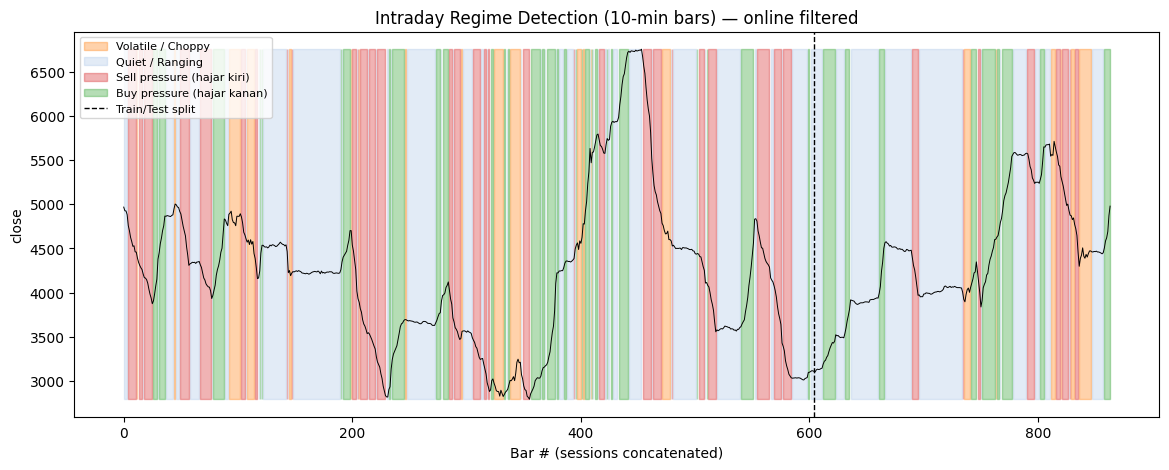

In [7]:
evaluate.report_metrics(df, truth=truth, tag="ALL")

fig, ax = plt.subplots(figsize=(14, 5))
evaluate.plot_intraday_regimes(df, split=split, ax=ax)
plt.show()
